<a href="https://colab.research.google.com/github/Machine-Learning-Visao-Computacional-T3/semana-02/blob/main/Pipeline_de_ML_E_Overfitting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importação das bibliotecas do projeto

In [ ]:
from sklearn.model_selection import train_test_split #separação do dataset em X_treino, X_teste, y_treino, y_teste
import numpy as np # manipulacao de dados
import matplotlib.pyplot as plt # visualização de dados (gráficos)
from sklearn.tree import DecisionTreeRegressor # modelo de ML
from sklearn import tree  # representacao visual/textual do modelo utilizado
import seaborn as sns # visualização/dataset

# Dados

In [ ]:
df = sns.load_dataset('tips') # dataset referente a dados de gorjeta
df.head(5)

# total_bill = valor total da conta
# tip = valor da gorjeta
# sex = sexo do cliente
# smoker = cliente fumante ou nao
# day = dia
# time = qual a refeicao
# size = tamanho

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# Separacao de Features e Target

In [ ]:
print(' --- separacao de features e target ---')


X_estudos = df[['total_bill', 'size']] # separacao das features/variaveis numericas
y_estudos = df['tip'] # separacao do target/alvo

 --- separacao de features e target ---


In [ ]:
# utilizacao do train_test_split para fazer o fatiamento da base de treino e de teste
# test_size = 0.20 significa que 20% da base vai para TESTE (PROVA) e 80% da base vai para TREINO (LISTA DE EXERCICIOS)

X_treino, X_teste, y_treino, y_teste = train_test_split(X_estudos, y_estudos, test_size=0.2, random_state=42)

print(f'total de registros na tabela de origem: {len(df)}')
print(f'total de registro para o treino: {len(X_treino)}')
print(f'total de registros do teste: {len(X_teste)}')

total de registros na tabela de origem: 244
total de registro para o treino: 195
total de registros do teste: 49


In [ ]:
print(" --- SIMULANDO DADOS ERRADOS PARA CRIAR UM OVERFITTING ARTIFICIAL")
# criando dados com erro/ruido de proposito

ruido = np.random.RandomState(1) # padronizando a geracao de numeros aleatorios com randomstate = 1
X_onda = np.sort(5 * ruido.rand(80, 1), axis=0) # criando as features aleatorias dentro de um range de 0 a 5
y_onda = np.sin(X_onda).ravel() # criando o target com uma funcao matematica de seno (sin) e transformando em um array unidimensional (uma lista simples)
y_onda[::5] += 3 * (0.5 - ruido.rand(16)) # adicionando outliers no target

 --- SIMULANDO DADOS ERRADOS PARA CRIAR UM OVERFITTING ARTIFICIAL


In [ ]:
y_onda

array([-1.1493464 ,  0.09131401,  0.09668352,  0.13651039,  0.19403525,
       -0.12383814,  0.26365828,  0.41252216,  0.44546446,  0.47215529,
       -0.26319138,  0.49351799,  0.60530013,  0.63450933,  0.64144608,
        1.09900119,  0.66957978,  0.66968122,  0.73574834,  0.75072053,
        1.4926134 ,  0.8363043 ,  0.8532893 ,  0.87144496,  0.97060533,
       -0.20183403,  0.99131122,  0.99472837,  0.99825213,  0.99999325,
        1.21570343,  0.98769965,  0.98591565,  0.9159044 ,  0.91406986,
       -0.51669013,  0.8775346 ,  0.87063055,  0.86993408,  0.86523559,
        0.37007575,  0.78464608,  0.63168655,  0.53722799,  0.45801971,
        0.08075119,  0.43272116,  0.34115328,  0.26769953,  0.20730318,
        1.34959235, -0.17645185, -0.20918837, -0.24990778, -0.28068224,
       -1.63529379, -0.31247075, -0.31458595, -0.32442911, -0.34965155,
       -0.29371122, -0.46921115, -0.56401144, -0.57215326, -0.57488849,
       -0.95586361, -0.75923066, -0.78043659, -0.85808859, -0.94

In [ ]:
# criando o modelo "aluno bom" que aprende os padroes e tendencias
modelo_ideal = DecisionTreeRegressor(max_depth=3) #instanciando o modelo DecisionTree
modelo_ideal.fit(X_onda, y_onda) #treinando o modelo com o .fit

DecisionTreeRegressor(max_depth=3)

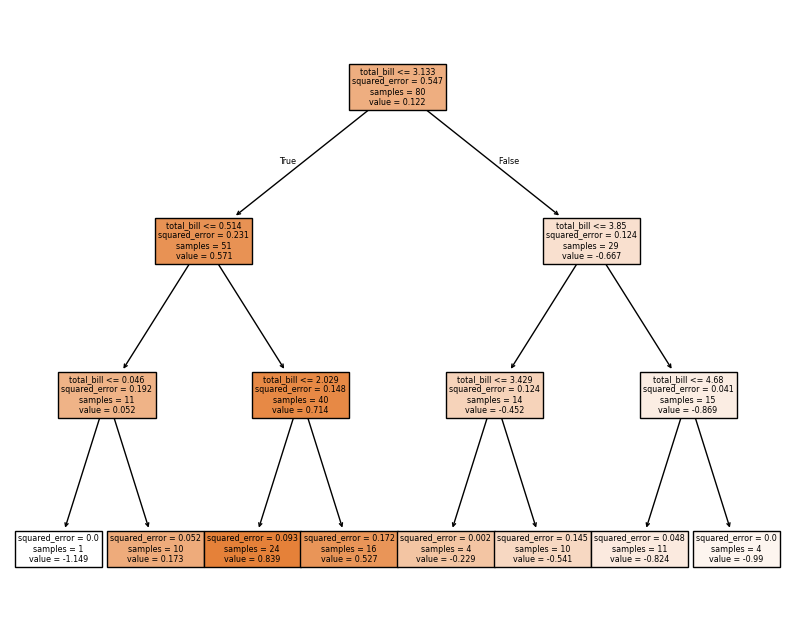

In [ ]:
# representacao visual do modelo de decisiontree "bom"

# text_representation = tree.export_text(modelo_ideal)
# print(text_representation)

fig = plt.figure(figsize=(10,8))
_ = tree.plot_tree(modelo_ideal,
                   feature_names=['total_bill', 'size'],
                   filled=True)

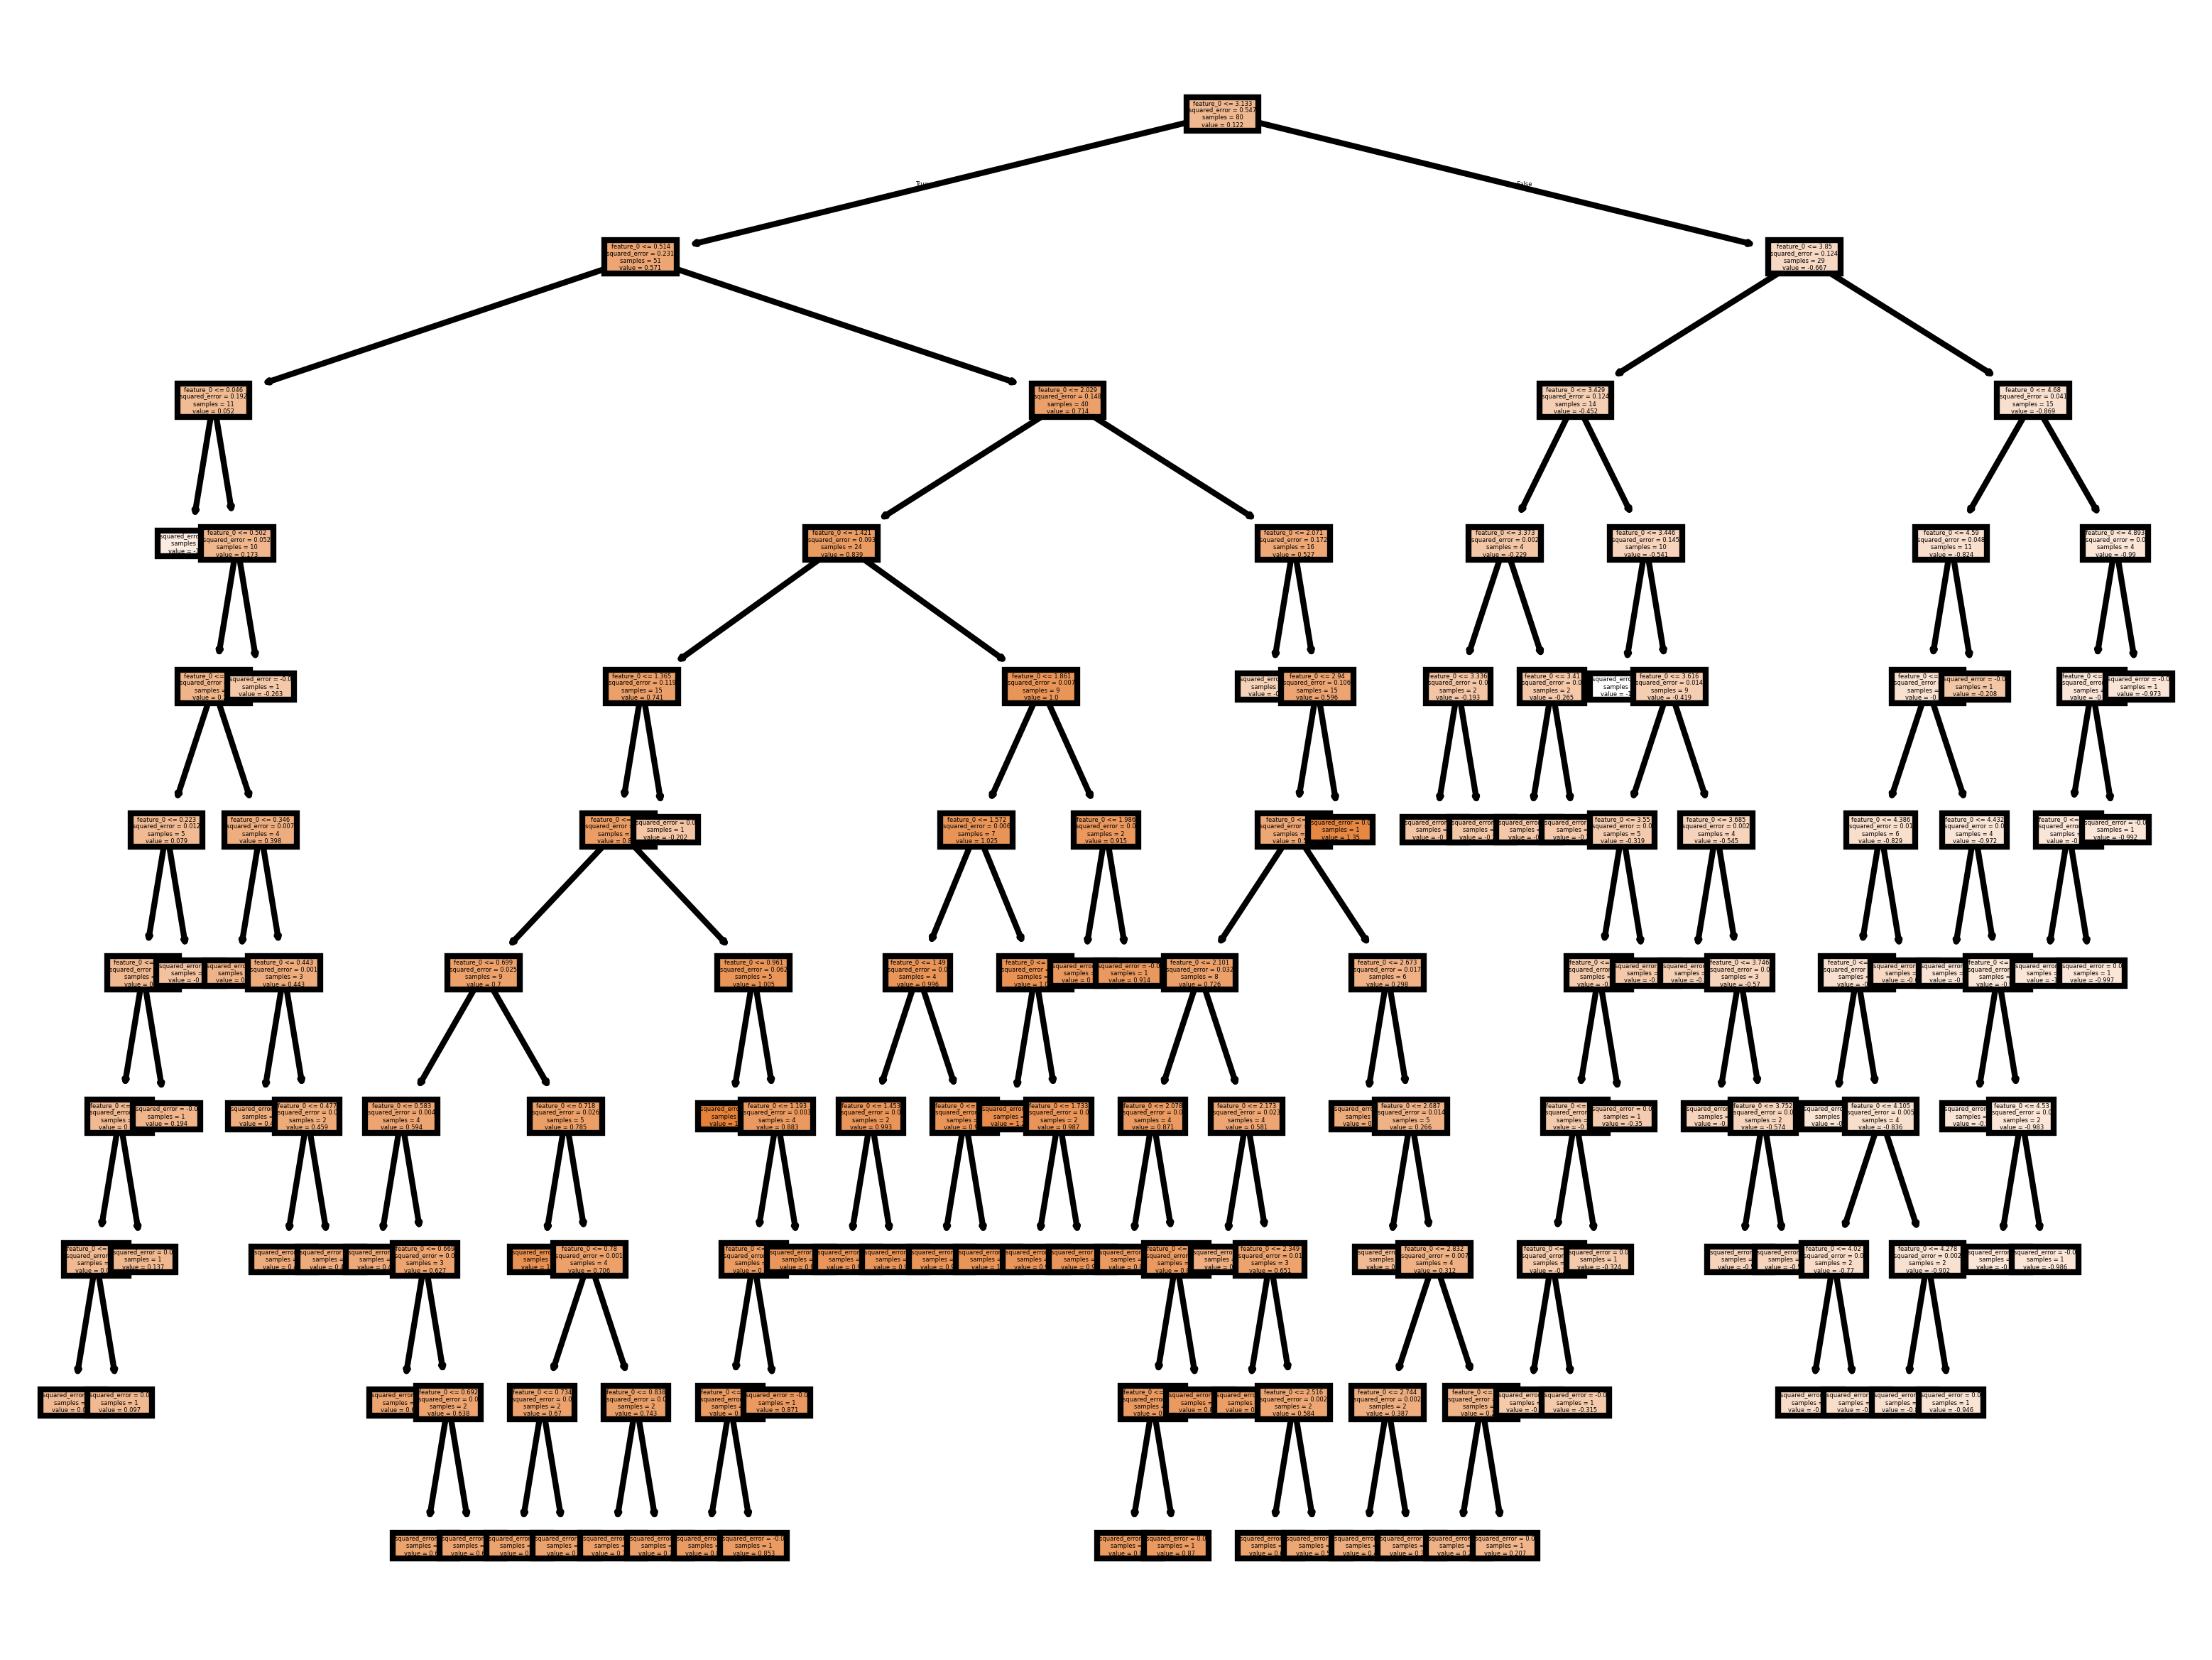

In [ ]:
# modelo overfittado (aprendeu demais)
modelo_decoreba = DecisionTreeRegressor(max_depth=15) # ramificações muito profundas da arvore de decisao
modelo_decoreba.fit(X_onda, y_onda)

fig = plt.figure(dpi=600)
_ = tree.plot_tree(modelo_decoreba,
                   feature_names = ['feature_0'],
                   filled=True)

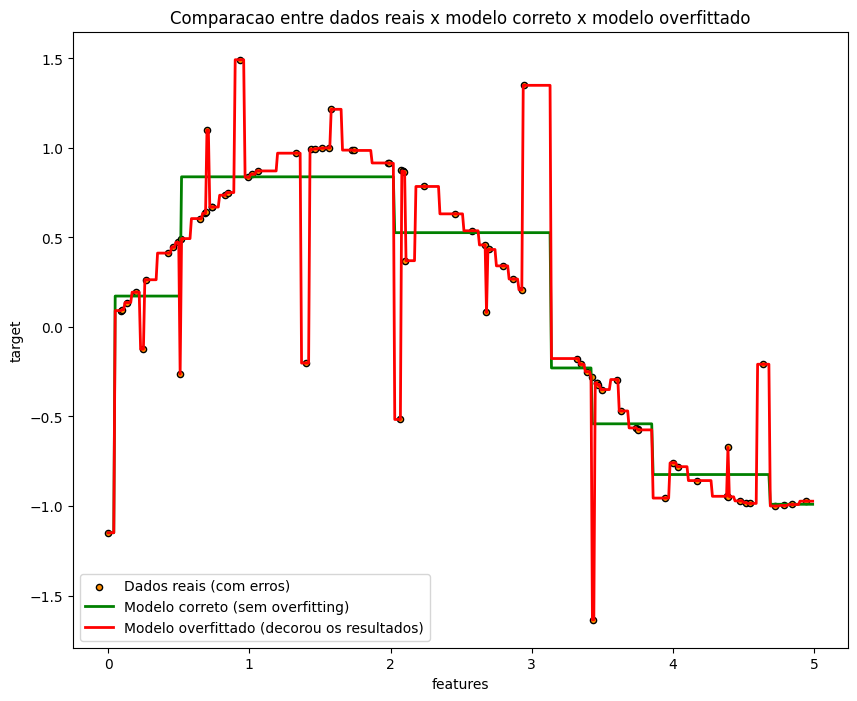

In [ ]:
# resultado final entre Dados Reais x Modelo Correto (aprendeu os padroes) x Modelo overfittado (decorou até as exceções)
X_teste_onda = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]

previsao_ideal = modelo_ideal.predict(X_teste_onda)
previsao_decoreba = modelo_decoreba.predict(X_teste_onda)

plt.figure(figsize=(10,8))
plt.scatter(X_onda, y_onda, s=20, edgecolor='black', c='darkorange', label='Dados reais (com erros)')
plt.plot(X_teste_onda, previsao_ideal, c='green', label='Modelo correto (sem overfitting)', linewidth=2)
plt.plot(X_teste_onda, previsao_decoreba, c='red', label='Modelo overfittado (decorou os resultados)', linewidth=2)
plt.xlabel('features')
plt.ylabel('target')
plt.title('Comparacao entre dados reais x modelo correto x modelo overfittado')
plt.legend()
plt.show()